In [1]:
#### Import Libararies

In [2]:
import numpy as np
import matplotlib.pyplot as plt

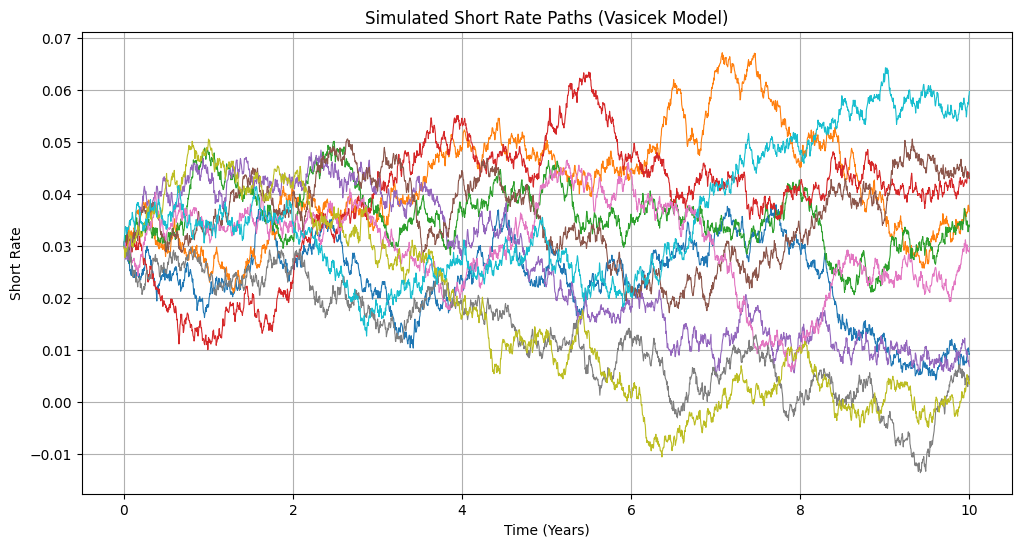

In [3]:
# Parameters
a = 0.1        # Mean reversion speed
b = 0.05       # Long-term mean
sigma = 0.01   # Volatility
r0 = 0.03      # Initial rate
T = 10         # Years
dt = 1/252     # Daily steps
n_sims = 10    # Number of simulations

N = int(T / dt)
t = np.linspace(0, T, N)

# Simulation function
def simulate_vasicek_paths(a, b, sigma, r0, T, dt, n_sims):
    N = int(T / dt)
    paths = np.zeros((n_sims, N))
    paths[:, 0] = r0

    for i in range(1, N):
        dr = a * (b - paths[:, i-1]) * dt + sigma * np.sqrt(dt) * np.random.randn(n_sims)
        paths[:, i] = paths[:, i-1] + dr

    return t, paths

t, vasicek_paths = simulate_vasicek_paths(a, b, sigma, r0, T, dt, n_sims)

# Plot
plt.figure(figsize=(12, 6))
for i in range(n_sims):
    plt.plot(t, vasicek_paths[i], lw=0.8)
plt.title('Simulated Short Rate Paths (Vasicek Model)')
plt.xlabel('Time (Years)')
plt.ylabel('Short Rate')
plt.grid(True)
plt.show()


Vasicek Bond Pricing Formula
$$P(t, T) = A(t,T)e^{-B(t,T)r} $$

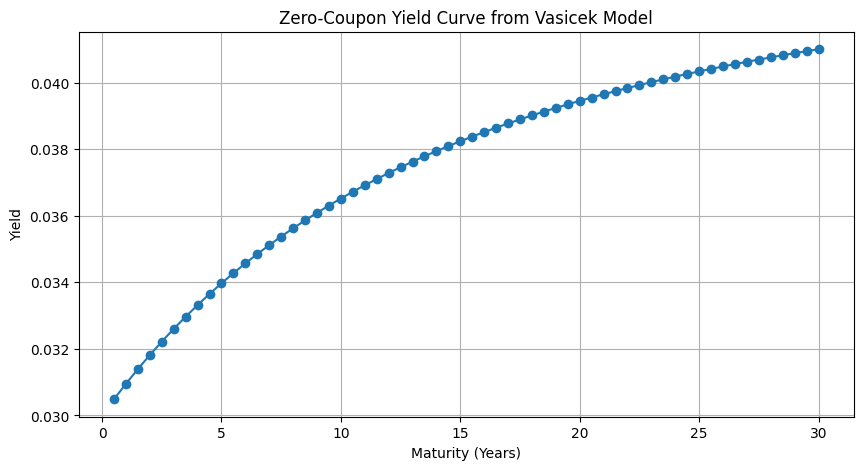

In [4]:
def vasicek_bond_price(a, b, sigma, r, t, T):
    B = (1 - np.exp(-a * (T - t))) / a
    A = np.exp((b - sigma**2 / (2 * a**2)) * (B - (T - t)) - (sigma**2 * B**2) / (4 * a))
    return A * np.exp(-B * r)

# Yield curve at t = 0
maturities = np.arange(0.5, 30.5, 0.5)  # 0.5 to 30 years
yields = [-np.log(vasicek_bond_price(a, b, sigma, r0, 0, T)) / T for T in maturities]

# Plot yield curve
plt.figure(figsize=(10, 5))
plt.plot(maturities, yields, marker='o')
plt.title('Zero-Coupon Yield Curve from Vasicek Model')
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield')
plt.grid(True)
plt.show()